In [ ]:
#dowlnload dziriBERT
tokenizer = AutoTokenizer.from_pretrained("alger-ia/dziribert")
model = AutoModel.from_pretrained("alger-ia/dziribert")




/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#etape 3 : split

In [ ]:

from sklearn.model_selection import train_test_split

# Séparer les features et les labels
X = twifil_copy
y = twifil_copy["Polarity Class"]

# Premier split: Train (70%) et Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Deuxième split: Val (50% de temp) et Test (50% de temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# Créer les DataFrames finaux
train_set = X_train.copy()
val_set = X_val.copy()
test_set = X_test.copy()

print("\nDistribution des classes (%):")
print("Train:")
print(train_set["Polarity Class"].value_counts(normalize=True) * 100)
print("\nValidation:")
print(val_set["Polarity Class"].value_counts(normalize=True) * 100)
print("\nTest:")
print(test_set["Polarity Class"].value_counts(normalize=True)* 100)


Distribution des classes (%):
Train:
Polarity Class
Positive    52.107829
Negative    34.843705
Neutral     13.048466
Name: proportion, dtype: float64

Validation:
Polarity Class
Positive    52.074967
Negative    34.805890
Neutral     13.119143
Name: proportion, dtype: float64

Test:
Polarity Class
Positive    52.139037
Negative    34.893048
Neutral     12.967914
Name: proportion, dtype: float64


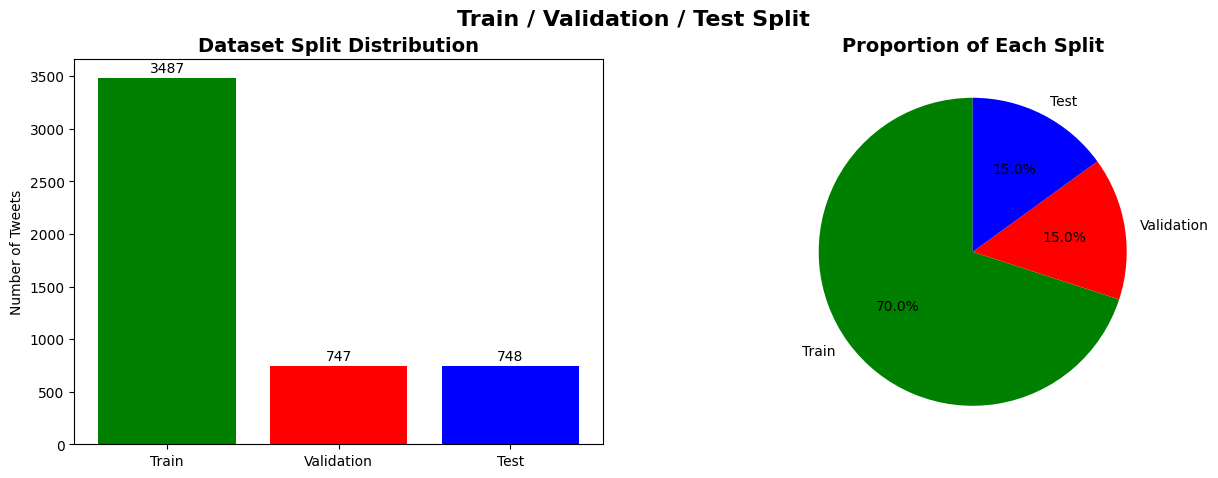

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 2.1 Taille des sets
sizes = [len(train_set), len(val_set), len(test_set)]
colors_bar = ['green', 'red', 'blue']
labels = ['Train','Validation','Test']

bars = axes[0].bar(labels, sizes, color=colors_bar)
axes[0].set_title('Dataset Split Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Tweets')

# Ajouter les valeurs sur les barres
for bar, size in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{size}', ha='center')


# 2.2 Pie chart des tailles
axes[1].pie(sizes, labels=labels, colors=colors_bar, autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Proportion of Each Split', fontsize=14, fontweight='bold')
plt.suptitle('Train / Validation / Test Split ',
             fontsize=16, fontweight='bold')
plt.show()


In [ ]:
#ETAPE 3 — Modèle Baseline

In [ ]:
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

train_set["label"] = train_set["Polarity Class"].str.lower().map(label_map)
val_set["label"] = val_set["Polarity Class"].str.lower().map(label_map)
test_set["label"] = test_set["Polarity Class"].str.lower().map(label_map)


In [ ]:
#trasform to HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_set[["clean_text", "label"]])
val_dataset = Dataset.from_pandas(val_set[["clean_text", "label"]])
test_dataset = Dataset.from_pandas(test_set[["clean_text", "label"]])


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "alger-ia/dziribert"

tokenizer = AutoTokenizer.from_pretrained(model_name)

id2label = {idx: label for label, idx in label_map.items()}
label2id = label_map

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print(f" Modèle chargé: {model_name}")
print(f"Classes: {label2id}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

 Modèle chargé: alger-ia/dziribert
Classes: {'negative': 0, 'neutral': 1, 'positive': 2}


In [ ]:
#tokenization
def tokenize_function(example):
    return tokenizer(
        example["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)


Map:   0%|          | 0/3487 [00:00<?, ? examples/s]

Map:   0%|          | 0/747 [00:00<?, ? examples/s]

Map:   0%|          | 0/748 [00:00<?, ? examples/s]

In [ ]:
# Définir le format pour PyTorch
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print(f" Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

 Train: 3487 | Val: 747 | Test: 748


In [ ]:
# ============================================================
# 5. MÉTRIQUES
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    f1_macro = f1_score(labels, predictions, average='macro')
    f1_per_class = f1_score(labels, predictions, average=None)
    precision, recall, _, _ = precision_recall_fscore_support(labels, predictions, average=None)
    accuracy = accuracy_score(labels, predictions)
    g_mean = np.sqrt(np.prod(recall))

    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_negative': f1_per_class[0],
        'f1_neutral': f1_per_class[1],
        'f1_positive': f1_per_class[2],
        'precision_negative': precision[0],
        'precision_neutral': precision[1],
        'precision_positive': precision[2],
        'recall_negative': recall[0],
        'recall_neutral': recall[1],
        'recall_positive': recall[2],
        'g_mean': g_mean
    }


In [ ]:
from transformers import TrainingArguments

# ============================================================
# 6. CONFIGURATION
# ============================================================

training_args = TrainingArguments(
    output_dir="./baseline_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    seed=42,
    report_to="none"
)

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, precision_recall_fscore_support, accuracy_score
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Negative,F1 Neutral,F1 Positive,Precision Negative,Precision Neutral,Precision Positive,Recall Negative,Recall Neutral,Recall Positive,G Mean
1,No log,0.680624,0.704150,0.633633,0.698582,0.447552,0.754765,0.648026,0.711111,0.746231,0.757692,0.326531,0.763496,0.434622
2,No log,0.716623,0.713521,0.656532,0.694444,0.509091,0.766061,0.717213,0.626866,0.724771,0.673077,0.428571,0.812339,0.484075
3,0.578011,0.946703,0.709505,0.648669,0.696498,0.482759,0.766749,0.704724,0.552632,0.741007,0.688462,0.428571,0.794344,0.484123
4,0.578011,1.046771,0.720214,0.670981,0.702595,0.538462,0.771887,0.730290,0.583333,0.741706,0.676923,0.500000,0.804627,0.521858
5,0.197261,1.162134,0.713521,0.660217,0.690763,0.519337,0.770552,0.722689,0.566265,0.737089,0.661538,0.479592,0.807198,0.506062


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1090, training_loss=0.3649001401498777, metrics={'train_runtime': 642.1801, 'train_samples_per_second': 27.15, 'train_steps_per_second': 1.697, 'total_flos': 1146845609521920.0, 'train_loss': 0.3649001401498777, 'epoch': 5.0})

In [ ]:
results = trainer.evaluate(test_dataset)

print(" RÉSULTATS BASELINE:")
print(f"Accuracy: {results['eval_accuracy']:.4f}")
print(f"F1-macro: {results['eval_f1_macro']:.4f}")
print(f"G-mean: {results['eval_g_mean']:.4f}")
print("\nF1 par classe:")
print(f"  Negative: {results['eval_f1_negative']:.4f}")
print(f"  Neutral: {results['eval_f1_neutral']:.4f}")
print(f"  Positive: {results['eval_f1_positive']:.4f}")
print("\nRecall par classe:")
print(f"  Negative: {results['eval_recall_negative']:.4f}")
print(f"  Neutral: {results['eval_recall_neutral']:.4f}")
print(f"  Positive: {results['eval_recall_positive']:.4f}")

 RÉSULTATS BASELINE:
Accuracy: 0.7099
F1-macro: 0.6671
G-mean: 0.5293

F1 par classe:
  Negative: 0.6947
  Neutral: 0.5484
  Positive: 0.7583

Recall par classe:
  Negative: 0.6973
  Neutral: 0.5258
  Positive: 0.7641


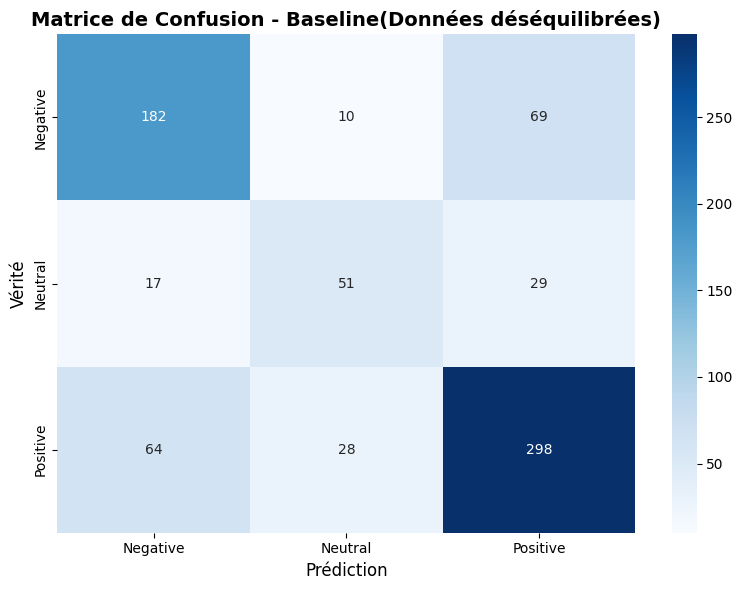

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prédictions sur le test set
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Matrice de Confusion - Baseline(Données déséquilibrées)',
          fontsize=14, fontweight='bold')
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Vérité', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import json

# Sauvegarder les résultats de la baseline
baseline_results = {
    'model': 'DziriBERT',
    'configuration': 'Baseline (données brutes déséquilibrées)',
    'f1_macro': results['eval_f1_macro'],
    'f1_positive': results['eval_f1_positive'],
    'f1_negative': results['eval_f1_negative'],
    'f1_neutral': results['eval_f1_neutral'],
    'accuracy': results['eval_accuracy'],
    'g_mean': results['eval_g_mean'],
    'precision_positive': results['eval_precision_positive'],
    'precision_negative': results['eval_precision_negative'],
    'precision_neutral': results['eval_precision_neutral'],
    'recall_positive': results['eval_recall_positive'],
    'recall_negative': results['eval_recall_negative'],
    'recall_neutral': results['eval_recall_neutral']
}

# Sauvegarder en JSON
with open('baseline_results.json', 'w', encoding='utf-8') as f:
    json.dump(baseline_results, f, indent=4, ensure_ascii=False)

print(" Résultats baseline sauvegardés dans 'baseline_results.json'")

 Résultats baseline sauvegardés dans 'baseline_results.json'
